In [103]:
# # To avoid issues with multiple OpenMP libraries being loaded
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os


#Statistical tests
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Plot
import seaborn as sns
import matplotlib.pyplot as plt

In [184]:
directory = '../hpc_result/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [185]:
df.head(5)

,model,attack,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,attack_successful,psnr_score,ssim_score,ergas_score,adversarial_image_path,original_probs,adversarial_probs,dataset_index
0,mobilenet_imagenet20_adv,fgsm,0,5,0,0,NaN,False,84.390099,0.999988,8.877092e+05,results/adversarial_images/adv_fgsm_src0_tgt5_...,"[1.0, 4.303542244787906e-11, 1.507875768691491...","[0.9999971389770508, 7.97165089494456e-09, 2.4...",0
1,mobilenet_imagenet20_adv,fgsm,0,7,0,0,NaN,False,84.892670,0.999990,1.451800e+06,results/adversarial_images/adv_fgsm_src0_tgt7_...,"[0.6130468249320984, 8.343882655026391e-06, 4....","[0.8348283171653748, 9.7318843472749e-05, 3.15...",1
2,mobilenet_imagenet20_adv,fgsm,0,10,0,0,NaN,False,84.441742,0.999988,1.249557e+06,results/adversarial_images/adv_fgsm_src0_tgt10...,"[1.0, 2.8384542979931204e-13, 2.49330483830748...","[1.0, 1.5219685234324487e-10, 3.25161902611781...",2
3,mobilenet_imagenet20_adv,fgsm,0,5,0,0,NaN,False,84.437363,0.999990,1.529932e+06,results/adversarial_images/adv_fgsm_src0_tgt5_...,"[1.0, 5.249876922075458e-12, 2.592430122568684...","[1.0, 2.1098221780757598e-10, 8.6023410617031e...",3
4,mobilenet_imagenet20_adv,fgsm,0,3,0,0,NaN,False,84.361328,0.999989,8.902008e+05,results/adversarial_images/adv_fgsm_src0_tgt3_...,"[0.9999822378158569, 2.076743665924141e-09, 7....","[0.9985185265541077, 1.3613777127829962e-07, 6...",4


In [135]:
nan_rows = df[df.isna().any(axis=1)]
nan_rows.head(5)

,model,attack,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,attack_successful,psnr_score,ssim_score,ergas_score,adversarial_image_path,original_probs,adversarial_probs,dataset_index
2719,mobilenet_imagenet20,cw,13,5,13,5,NaN,True,73.694588,0.999942,2.337422e+06,results/adversarial_images/adv_cw_src13_tgt5_i...,"[0.006450810004025698, 0.005068792030215263, 0...","[1.843638301579631e-06, 2.9630929930135608e-05...",2751
2735,mobilenet_imagenet20,cw,13,0,13,0,NaN,True,74.366692,0.999948,4.877596e+06,results/adversarial_images/adv_cw_src13_tgt0_i...,"[0.000735801993869245, 3.0805214919382706e-05,...","[0.9999635219573975, 2.046179588433006e-06, 2....",2767
3164,mobilenet_imagenet20,cw,16,6,16,6,NaN,True,71.348053,0.999892,9.239040e+00,results/adversarial_images/adv_cw_src16_tgt6_i...,"[0.0012851337669417262, 0.005002961028367281, ...","[0.0002160243602702394, 0.00047410628758370876...",3208
3207,mobilenet_imagenet20,cw,16,15,16,15,NaN,True,72.082291,0.999916,9.729756e+00,results/adversarial_images/adv_cw_src16_tgt15_...,"[0.0004962122766301036, 0.0023140981793403625,...","[1.163895603895071e-06, 7.718431902503653e-07,...",3251
3383,mobilenet_imagenet20,cw,17,19,17,19,NaN,True,74.615463,0.999951,4.739876e+06,results/adversarial_images/adv_cw_src17_tgt19_...,"[3.2085150451166555e-05, 0.0003138123138342052...","[8.370030002424755e-08, 1.0470588449607021e-06...",3431


In [136]:
df.loc[df['first_success_iter'].isna(), 'attack_successful'] = False
df['first_success_iter'] = df['first_success_iter'].fillna(1000000)

In [138]:
model_counts = df['model'].value_counts()
print(model_counts)

model
mobilenet_imagenet20     11808
resnet_imagenet20_adv    11808
resnet_imagenet20        11808
swin_imagenet20          11808
Name: count, dtype: int64


In [193]:
df_mobilenet = df[df['model'] == 'mobilenet_imagenet20'].copy()
df_resnet    = df[df['model'] == 'resnet_imagenet20'].copy()
df_swin      = df[df['model'] == 'swin_imagenet20'].copy()

In [194]:
df_base = pd.concat([df_mobilenet, df_resnet, df_swin], ignore_index=True)

In [195]:
df_swin.describe()

,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11603.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.457063,9.532520,9.355268,15.612773,83.905938,0.999984,1.245456e+06,1994.761179
std,5.787412,5.751423,5.793688,5.739737,20.667205,6.004384,0.000022,1.372835e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,69.669830,0.999818,2.994905e-01,0.000000
25%,5.000000,4.000000,4.000000,4.000000,2.000000,76.975641,0.999969,1.728767e+01,999.750000
50%,10.000000,9.000000,10.000000,9.000000,4.000000,85.746246,0.999996,7.930338e+05,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,25.000000,89.091692,0.999998,1.355259e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,99.000000,94.261765,1.000000,7.399810e+06,3991.000000


In [189]:
df_resnet.describe()

,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11384.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.437754,9.617124,10.096206,13.090654,84.160017,0.999981,1.374580e+06,1994.761179
std,5.787412,5.761487,5.813918,5.699668,16.266192,7.600524,0.000027,1.700549e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,68.699532,0.999802,2.303667e-01,0.000000
25%,5.000000,4.000000,5.000000,6.000000,3.000000,75.206417,0.999962,1.975413e+01,999.750000
50%,10.000000,9.000000,10.000000,10.000000,6.000000,85.934151,0.999997,6.732922e+05,1995.500000
75%,15.000000,14.000000,15.000000,15.000000,17.000000,91.518902,0.999999,1.298696e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,99.000000,94.968498,1.000000,7.925248e+06,3991.000000


In [191]:
df_mobilenet.describe()

,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11770.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.491531,9.542937,9.480268,9.451742,84.300337,0.999984,1.257954e+06,1994.761179
std,5.787412,5.761788,5.796339,5.746246,12.688136,6.726088,0.000023,1.472833e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,69.516365,0.999830,2.535299e-01,0.000000
25%,5.000000,5.000000,5.000000,4.000000,2.000000,76.731361,0.999970,1.789010e+01,999.750000
50%,10.000000,9.000000,10.000000,9.000000,3.000000,85.879719,0.999996,7.395943e+05,1995.500000
75%,15.000000,15.000000,15.000000,14.000000,14.000000,90.471199,0.999999,1.317419e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,99.000000,94.736526,1.000000,8.026403e+06,3991.000000


### Successrate models

In [196]:
success_rate_mobilenet = df_mobilenet['attack_successful'].mean()
success_rate_resnet = df_resnet['attack_successful'].mean()
success_rate_swin = df_swin['attack_successful'].mean()

print(success_rate_mobilenet,success_rate_resnet,success_rate_swin)

0.7932757452574526 0.6026422764227642 0.8225779132791328


### Successrate Attacktypes

In [140]:
success_rates = df_mobilenet.groupby('attack')['attack_successful'].mean()
print(success_rates)

attack
cw      0.474593
fgsm    0.908537
pgd     0.994411
Name: attack_successful, dtype: float64


In [141]:
success_rates = df_resnet.groupby('attack')['attack_successful'].mean()
print(success_rates)

attack
cw      0.140752
fgsm    0.688516
pgd     0.975102
Name: attack_successful, dtype: float64


In [142]:
success_rates = df_swin.groupby('attack')['attack_successful'].mean()
print(success_rates)

attack
cw      0.670732
fgsm    0.835874
pgd     0.958587
Name: attack_successful, dtype: float64


In [143]:
success_rates = df.groupby('attack')['attack_successful'].mean()
print(success_rates)

attack
cw      0.387830
fgsm    0.743458
pgd     0.864456
Name: attack_successful, dtype: float64


In [197]:
success_rates = df_base.groupby('attack')['first_success_iter'].mean()
print(success_rates)

attack
cw       2.855458
fgsm     6.408269
pgd     29.014141
Name: first_success_iter, dtype: float64


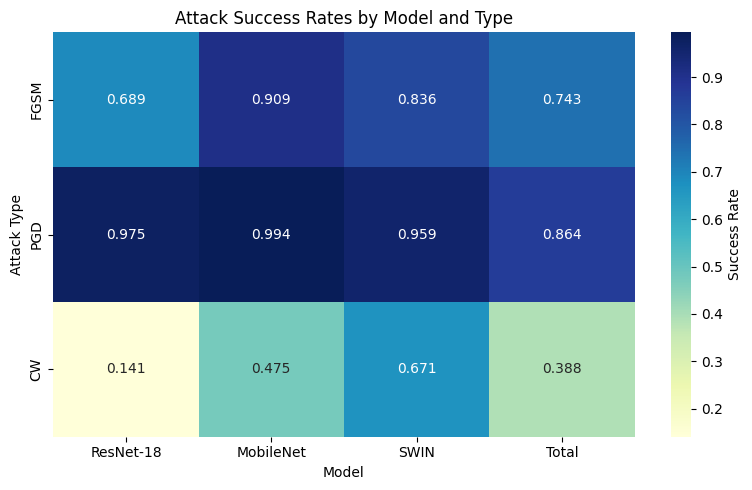

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from your table
data = {
    'ResNet-18': [0.688516, 0.975102, 0.140752],
    'MobileNet': [0.908537, 0.994411, 0.474593],
    'SWIN': [0.835874, 0.958587, 0.670732],
    'Total': [0.743458, 0.864456, 0.387830],
}
attacks = ['FGSM', 'PGD', 'CW']

# Create DataFrame
df = pd.DataFrame(data, index=attacks)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Success Rate'})
plt.title("Attack Success Rates by Model and Type")
plt.xlabel("Model")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.show()


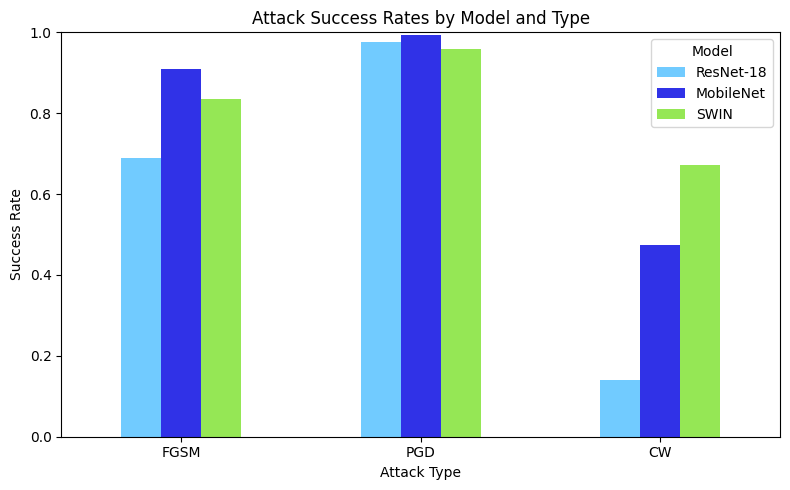

In [181]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    'ResNet-18': [0.688516, 0.975102, 0.140752],
    'MobileNet': [0.908537, 0.994411, 0.474593],
    'SWIN': [0.835874, 0.958587, 0.670732],
}
attacks = ['FGSM', 'PGD', 'CW']
df = pd.DataFrame(data, index=attacks)

# Custom colors for each model
custom_colors = ['#71cbff', '#3032e7', '#95e755']  # blue, orange, green

# Plot with custom colors
df.plot(kind='bar', figsize=(8, 5), color=custom_colors)
plt.title("Attack Success Rates by Model and Type")
plt.ylabel("Success Rate")
plt.xlabel("Attack Type")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()


# Stastistical tests

In [150]:
model = smf.mixedlm(
    "psnr_score ~ model * attack",     # fixed effects: model, attack, and interaction
    df_base,
    groups="dataset_index"                  # random intercept per image
)
result = model.fit()

# Print the summary
print(result.summary())


                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          psnr_score 
No. Observations:            35424            Method:                      REML       
No. Groups:                  3936             Scale:                       1.4203     
Min. group size:             9                Log-Likelihood:              -58774.3681
Max. group size:             9                Converged:                   Yes        
Mean group size:             9.0                                                      
--------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z     P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 75.583    0.021 3570.888 0.000 75.541 75.624
model[T.resnet_imagenet20]                -1.356    0.027  -50.470 0

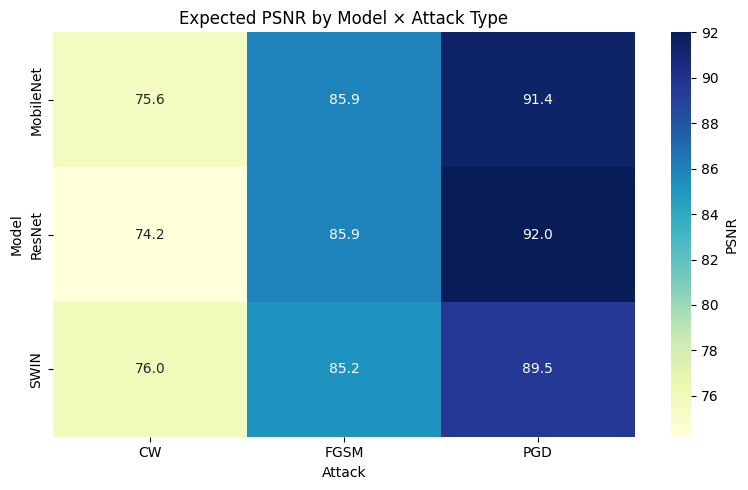

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Manually enter your values (rows = models, columns = attacks)
data = [
    [75.6, 85.9, 91.4],  # MobileNet
    [74.2, 85.9, 92.0],  # ResNet
    [76.0, 85.2, 89.5],  # SWIN
]

# 🏷️ Row and column labels
models = ['MobileNet', 'ResNet', 'SWIN']
attacks = ['CW', 'FGSM', 'PGD']

# Create a DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

#Generate heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'PSNR'})
plt.title('Expected PSNR by Model × Attack Type')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


In [155]:
model = smf.mixedlm(
    "ergas_score ~ model * attack",     # fixed effects: model, attack, and interaction
    df_base,
    groups="dataset_index"                  # random intercept per image
)
result = model.fit()

# Print the summary
print(result.summary())


                                    Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                ergas_score      
No. Observations:                 35424                  Method:                            REML             
No. Groups:                       3936                   Scale:                             621623085254.4215
Min. group size:                  9                      Log-Likelihood:                    -535971.4440     
Max. group size:                  9                      Converged:                         Yes              
Mean group size:                  9.0                                                                        
-------------------------------------------------------------------------------------------------------------
                                               Coef.        Std.Err.    z     P>|z|    [0.025       0.975]   
----------------------------------------------

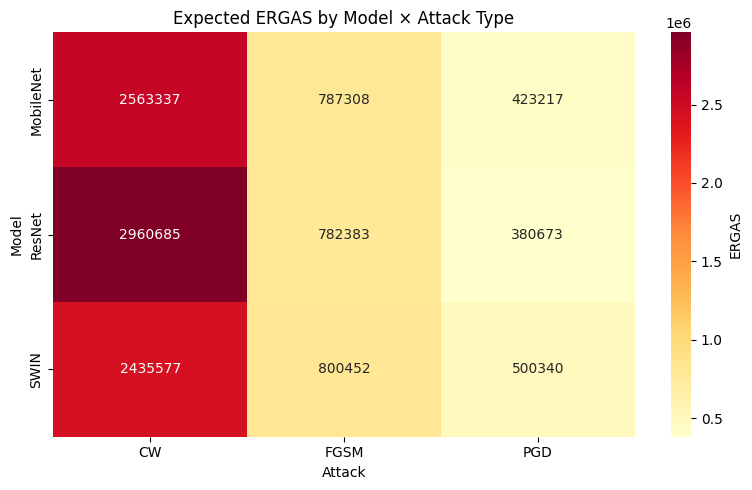

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Intercept
base = 2563337.320

# ERGAS values (rounded for clarity)
data = [
    [base,  # MobileNet + CW (baseline)
     base + -1776029.176,  # MobileNet + FGSM
     base + -2140119.934],  # MobileNet + PGD

    [base + 397347.726,  # ResNet + CW
     base + 397347.726 + -1776029.176 + -402272.931,  # ResNet + FGSM
     base + 397347.726 + -2140119.934 + -439892.219],  # ResNet + PGD

    [base + -127760.401,  # SWIN + CW
     base + -127760.401 + -1776029.176 + 140904.526,  # SWIN + FGSM
     base + -127760.401 + -2140119.934 + 204882.535],  # SWIN + PGD
]

# Row and column labels
models = ['MobileNet', 'ResNet', 'SWIN']
attacks = ['CW', 'FGSM', 'PGD']

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'ERGAS'})
plt.title('Expected ERGAS by Model × Attack Type')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


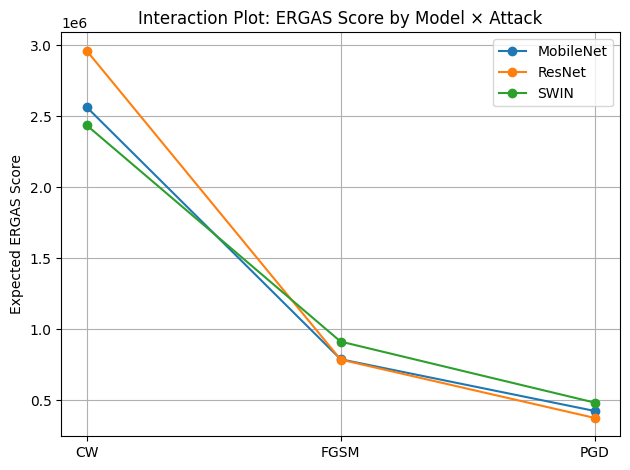

In [175]:
import matplotlib.pyplot as plt

# Manually input adjusted means for each model × attack combination
models = ['MobileNet', 'ResNet', 'SWIN']
attacks = ['CW', 'FGSM', 'PGD']

# Example values (replace with actual marginal means from your model)
ergas_means = {
    'MobileNet':    [2563337, 787307, 423217],  # Intercept + attack main effects
    'ResNet':       [2960685, 785015, 374145],  # Intercept + model + attack + interaction
    'SWIN':         [2435577, 911784, 482219]   # Intercept + model + attack + interaction
}

for model, scores in ergas_means.items():
    plt.plot(attacks, scores, label=model, marker='o')

plt.ylabel('Expected ERGAS Score')
plt.title('Interaction Plot: ERGAS Score by Model × Attack')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### KL divergence in probability distribution

In [173]:
df_base.head(5)

,model,attack,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,attack_successful,psnr_score,ssim_score,ergas_score,adversarial_image_path,original_probs,adversarial_probs,dataset_index,kl_divergence
0,mobilenet_imagenet20,cw,0,1,0,1,2.0,True,74.982132,0.999953,2486971.00,results/adversarial_images/adv_cw_src0_tgt1_id...,"[0.9922124743461609, 0.00013835911522619426, 0...","[0.025619857013225555, 0.39093512296676636, 0....",0,3.611501
1,mobilenet_imagenet20,cw,0,18,0,15,2.0,False,77.157402,0.999971,3537286.00,results/adversarial_images/adv_cw_src0_tgt18_i...,"[0.9983968138694763, 4.403488492243923e-05, 1....","[0.17118822038173676, 0.022171422839164734, 0....",1,1.753048
2,mobilenet_imagenet20,cw,0,7,0,7,2.0,True,75.021255,0.999955,3639137.00,results/adversarial_images/adv_cw_src0_tgt7_id...,"[0.999265730381012, 1.2124605746066663e-05, 5....","[0.005473548546433449, 0.00010521702643018216,...",2,5.203043
3,mobilenet_imagenet20,cw,0,8,0,0,2.0,False,79.135536,0.999982,2816849.50,results/adversarial_images/adv_cw_src0_tgt8_id...,"[0.997897744178772, 0.0002516777894925326, 2.3...","[0.6428641080856323, 0.002640338847413659, 0.0...",3,0.430536
4,mobilenet_imagenet20,cw,0,7,0,7,1.0,True,74.618340,0.999951,2692428.75,results/adversarial_images/adv_cw_src0_tgt7_id...,"[0.9939563870429993, 0.00015116743452381343, 3...","[0.004608482588082552, 0.0003776552330236882, ...",4,5.333574


In [161]:
df_base["original_probs"] = df_base["original_probs"].apply(ast.literal_eval)
df_base["adversarial_probs"] = df_base["adversarial_probs"].apply(ast.literal_eval)

In [162]:
def kl_divergence(p, q):
    # Convert to tensors
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    p = p + epsilon
    q = q + epsilon

    return F.kl_div(q.log(), p, reduction="sum").item()  

In [165]:
df_base["kl_divergence"] = df_base.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


In [167]:
print(df_base.groupby("attack")["kl_divergence"].mean())

attack
cw      2.115369
fgsm    3.794806
pgd     7.560499
Name: kl_divergence, dtype: float64


In [168]:
print(df_base[["kl_divergence", "psnr_score"]].corr())

               kl_divergence  psnr_score
kl_divergence       1.000000    0.446686
psnr_score          0.446686    1.000000


In [174]:
model = smf.mixedlm("kl_divergence ~ model * attack", data=df_base, groups=df_base["dataset_index"])
result = model.fit()

print(result.summary())

                        Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         kl_divergence
No. Observations:           35424           Method:                     REML         
No. Groups:                 3936            Scale:                      9.3841       
Min. group size:            9               Log-Likelihood:             -92080.8216  
Max. group size:            9               Converged:                  Yes          
Mean group size:            9.0                                                      
-------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  2.101    0.054  38.974 0.000  1.996  2.207
model[T.resnet_imagenet20]                -1.341    0.069 -19.425 0.000 -1.477

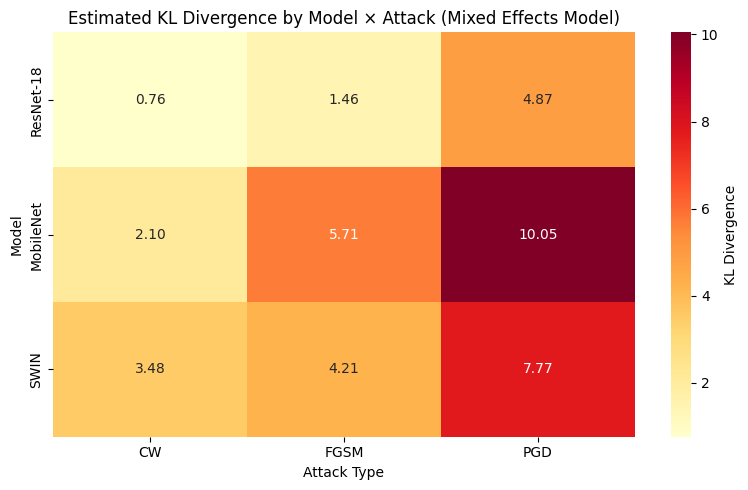

In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstruct KL divergence values by adding relevant coefficients to the Intercept
intercept = 2.101
coeffs = {
    "ResNet-18": {
        "FGSM": intercept + (-1.341) + 3.607 + (-2.905),
        "PGD":  intercept + (-1.341) + 7.947 + (-3.842),
        "CW":   intercept + (-1.341)
    },
    "MobileNet": {
        "FGSM": intercept + 3.607,
        "PGD":  intercept + 7.947,
        "CW":   intercept
    },
    "SWIN": {
        "FGSM": intercept + 1.383 + 3.607 + (-2.878),
        "PGD":  intercept + 1.383 + 7.947 + (-3.663),
        "CW":   intercept + 1.383
    }
}

# Convert to DataFrame
df = pd.DataFrame(coeffs).T  # Transpose to have models as rows
df = df[["CW", "FGSM", "PGD"]]  # Ensure correct column order

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'KL Divergence'})
plt.title("Estimated KL Divergence by Model × Attack (Mixed Effects Model)")
plt.xlabel("Attack Type")
plt.ylabel("Model")
plt.tight_layout()
plt.show()
